In [7]:
!pip install librosa spafe sounddevice
import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display
from scipy.fft import fft, fftfreq
from spafe.features.gfcc import gfcc


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.0/94.0 kB 3.7 MB/s eta 0:00:00


# Упражнения

1. Запишите два разных звука
1. Вычислить их спектральные характеристики (спектр, MFCC, GFCC)
1. Построение спектрограммы
1. Проанализируйте их сходства и различия

In [8]:
fs = 44100
duration = 2.0
t = np.linspace(0, duration, int(fs * duration))

sound1 = 0.5 * np.sin(2 * np.pi * 440 * t) + 0.2 * np.sin(2 * np.pi * 880 * t)
sound2 = np.random.uniform(-0.2, 0.2, len(t))


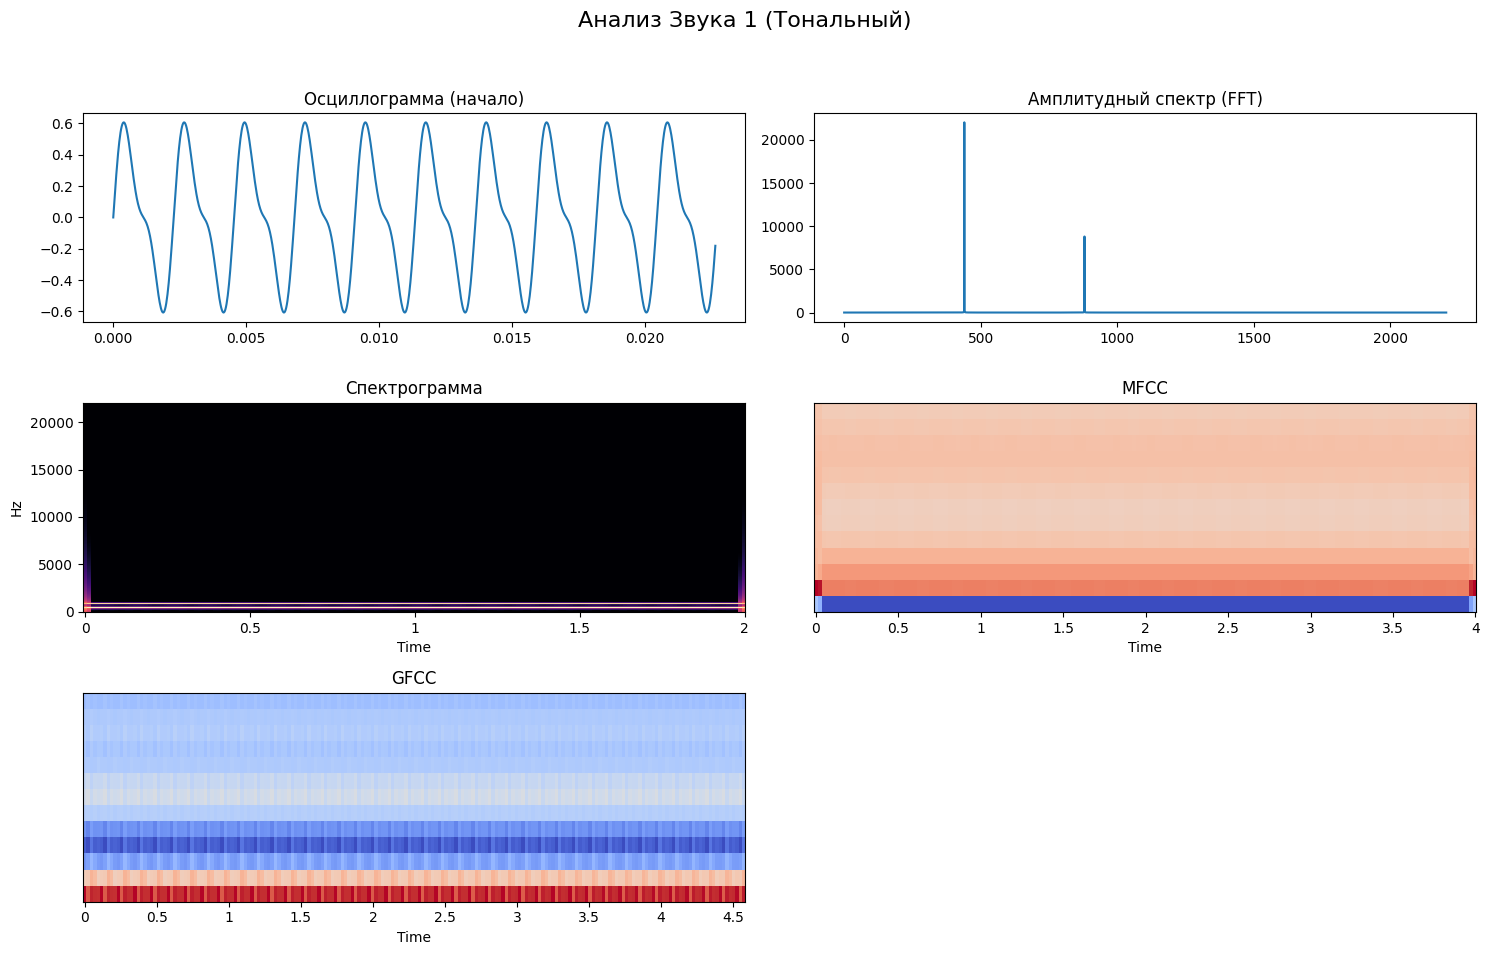

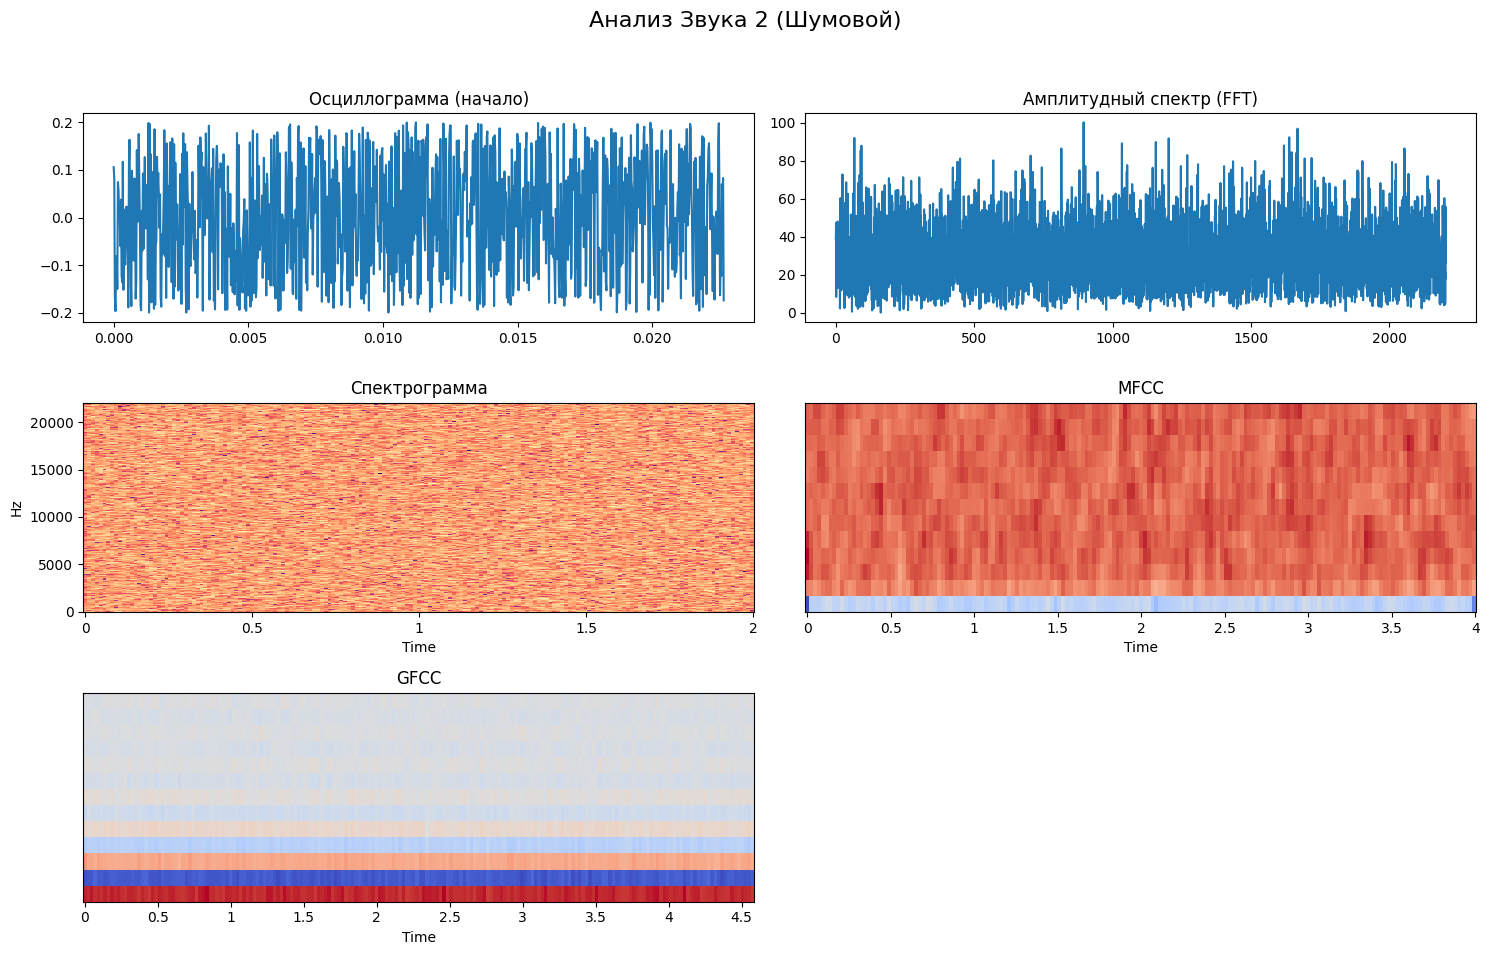

In [9]:
def analyze_sound(y, sr, title):
    plt.figure(figsize=(15, 10))
    plt.suptitle(title, fontsize=16)

    plt.subplot(3, 2, 1)
    plt.plot(t[:1000], y[:1000])
    plt.title("Осциллограмма (начало)")

    plt.subplot(3, 2, 2)
    n = len(y)
    yf = fft(y)
    xf = fftfreq(n, 1/sr)
    plt.plot(xf[:n//20], np.abs(yf[:n//20]))
    plt.title("Амплитудный спектр (FFT)")

    plt.subplot(3, 2, 3)
    D = librosa.amplitude_to_db(np.abs(librosa.stft(y)), ref=np.max)
    librosa.display.specshow(D, sr=sr, x_axis='time', y_axis='hz')
    plt.title("Спектрограмма")

    plt.subplot(3, 2, 4)
    mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    librosa.display.specshow(mfccs, x_axis='time')
    plt.title("MFCC")

    plt.subplot(3, 2, 5)
    gfccs = gfcc(y, fs=sr, num_ceps=13).T
    librosa.display.specshow(gfccs, x_axis='time')
    plt.title("GFCC")

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

analyze_sound(sound1, fs, "Анализ Звука 1 (Тональный)")
analyze_sound(sound2, fs, "Анализ Звука 2 (Шумовой)")

- Спектр (FFT):
  - Звук 1 (Тон): Имеет ярко выраженные пики на частотах 440 Гц и 880 Гц. Это линейчатый спектр, характерный для музыкальных инструментов или голоса.
  - Звук 2 (Шум): Спектр "плоский" или хаотичный. Энергия распределена по всем частотам примерно равномерно. Пиков нет.
- Спектрограмма:
  - Звук 1: Мы видим четкие горизонтальные линии. Это означает, что частота звука стабильна во времени.
  - Звук 2: Выглядит как равномерно закрашенный фон ("снег" на телевизоре). Это признак нестационарного или широкополосного шума.
- MFCC и GFCC:
  - У Звука 1 коэффициенты имеют более структурированный вид, так как человеческое ухо четко выделяет высоту этого звука.
  - У Звука 2 коэффициенты менее вариативны, так как шум не имеет "мелодической" структуры. GFCC обычно лучше выделяет детали в низкочастотной области по сравнению с MFCC.

Итоговое различие: Звук 1 является детерминированным и периодическим, его легко предсказать и анализировать по высоте тона. Звук 2 является стохастическим, его основные характеристики — это общая мощность и распределение частот.
